# Content

**The Book-Crossing dataset comprises three files**

*Users*

Contains the users. Note that user IDs (User-ID) have been anonymized and map to integers. Demographic data is provided (Location, Age) if available. Otherwise, these fields contain NULL values.

*Books*


Books are identified by their respective ISBN. Invalid ISBNs have already been removed from the dataset. Moreover, some content-based information is given (Book-Title, Book-Author, Year-Of-Publication, Publisher), obtained from Amazon Web Services. Note that in the case of several authors, only the first is provided. URLs linking to cover images are also given, appearing in three different flavors (Image-URL-S, Image-URL-M, Image-URL-L), i.e., small, medium, large. These URLs point to the Amazon website.

*Ratings*


Contains the book rating information. Ratings (Book-Rating) are either explicit, expressed on a scale from 1-10 (higher values denoting higher appreciation), or implicit, expressed by 0.

**Importing Libraries**

In [ ]:
import numpy as np # linear algebra
import pandas as pd # data processing
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import warnings; warnings.simplefilter('ignore')

**Book Data**

In [ ]:
book_data = pd.read_csv("/content/drive/MyDrive/book-recommendation/data/raw/Books.csv")
book_data.head()

,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
0,0195153448,Classical Mythology,Mark P. O. Morford,2002,Oxford University Press,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...
1,0002005018,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...
2,0060973129,Decision in Normandy,Carlo D'Este,1991,HarperPerennial,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...
3,0374157065,Flu: The Story of the Great Influenza Pandemic...,Gina Bari Kolata,1999,Farrar Straus Giroux,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...
4,0393045218,The Mummies of Urumchi,E. J. W. Barber,1999,W. W. Norton &amp; Company,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...


In [ ]:
book_data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271360 entries, 0 to 271359
Data columns (total 8 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   ISBN                 271360 non-null  object
 1   Book-Title           271360 non-null  object
 2   Book-Author          271358 non-null  object
 3   Year-Of-Publication  271360 non-null  object
 4   Publisher            271358 non-null  object
 5   Image-URL-S          271360 non-null  object
 6   Image-URL-M          271360 non-null  object
 7   Image-URL-L          271357 non-null  object
dtypes: object(8)
memory usage: 16.6+ MB


In [ ]:
book_data.shape


(271360, 8)

**users data**

In [ ]:
users_data= pd.read_csv('/content/drive/MyDrive/book-recommendation/data/raw/Users.csv')
users_data.head()

,User-ID,Location,Age
0,1,"nyc, new york, usa",NaN
1,2,"stockton, california, usa",18.0
2,3,"moscow, yukon territory, russia",NaN
3,4,"porto, v.n.gaia, portugal",17.0
4,5,"farnborough, hants, united kingdom",NaN


In [ ]:
users_data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 278858 entries, 0 to 278857
Data columns (total 3 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   User-ID   278858 non-null  int64  
 1   Location  278858 non-null  object 
 2   Age       168096 non-null  float64
dtypes: float64(1), int64(1), object(1)
memory usage: 6.4+ MB


In [ ]:
users_data.shape


(278858, 3)


**Ratings Data**

In [ ]:
ratings_data = pd.read_csv("/content/drive/MyDrive/book-recommendation/data/raw/Ratings.csv")
ratings_data.head()

,User-ID,ISBN,Book-Rating
0,276725,034545104X,0
1,276726,0155061224,5
2,276727,0446520802,0
3,276729,052165615X,3
4,276729,0521795028,6


In [ ]:
ratings_data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1149780 entries, 0 to 1149779
Data columns (total 3 columns):
 #   Column       Non-Null Count    Dtype 
---  ------       --------------    ----- 
 0   User-ID      1149780 non-null  int64 
 1   ISBN         1149780 non-null  object
 2   Book-Rating  1149780 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 26.3+ MB


In [ ]:
ratings_data.shape


(1149780, 3)


# **Data Preparation (Data Cleaning and Feature Engineering)**

In [ ]:
# droping the url
book_data.drop(['Image-URL-S', 'Image-URL-M', 'Image-URL-L'], axis= 1, inplace= True)

In [ ]:
# replacing '-' with '_' and features name in lower case
book_data.columns= book_data.columns.str.strip().str.lower().str.replace('-', '_')
users_data.columns= users_data.columns.str.strip().str.lower().str.replace('-', '_')
ratings_data.columns= ratings_data.columns.str.strip().str.lower().str.replace('-', '_')

In [ ]:
book_data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271360 entries, 0 to 271359
Data columns (total 5 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   isbn                 271360 non-null  object
 1   book_title           271360 non-null  object
 2   book_author          271358 non-null  object
 3   year_of_publication  271360 non-null  object
 4   publisher            271358 non-null  object
dtypes: object(5)
memory usage: 10.4+ MB



Let's see null values in book_data.

In [ ]:
print(book_data.isnull().sum())


isbn                   0
book_title             0
book_author            2
year_of_publication    0
publisher              2
dtype: int64


In [ ]:
# nan values in particular column
book_data.loc[(book_data['book_author'].isnull()),: ]

,isbn,book_title,book_author,year_of_publication,publisher
118033,0751352497,A+ Quiz Masters:01 Earth,NaN,1999,Dorling Kindersley
187689,9627982032,The Credit Suisse Guide to Managing Your Perso...,NaN,1995,Edinburgh Financial Publishing


In [ ]:
# nan values in particular column
book_data.loc[(book_data['publisher'].isnull()),: ]

,isbn,book_title,book_author,year_of_publication,publisher
128890,193169656X,Tyrant Moon,Elaine Corvidae,2002,NaN
129037,1931696993,Finders Keepers,Linnea Sinclair,2001,NaN


We pointed null values in 'book_author' and 'publisher' feature.

Let's look at the unique years to realize the time period as this dataset was created in 2004.

In [ ]:
# getting unique value from 'year_of_publication' feature
book_data['year_of_publication'].unique()

array([2002, 2001, 1991, 1999, 2000, 1993, 1996, 1988, 2004, 1998, 1994,
       2003, 1997, 1983, 1979, 1995, 1982, 1985, 1992, 1986, 1978, 1980,
       1952, 1987, 1990, 1981, 1989, 1984, 0, 1968, 1961, 1958, 1974,
       1976, 1971, 1977, 1975, 1965, 1941, 1970, 1962, 1973, 1972, 1960,
       1966, 1920, 1956, 1959, 1953, 1951, 1942, 1963, 1964, 1969, 1954,
       1950, 1967, 2005, 1957, 1940, 1937, 1955, 1946, 1936, 1930, 2011,
       1925, 1948, 1943, 1947, 1945, 1923, 2020, 1939, 1926, 1938, 2030,
       1911, 1904, 1949, 1932, 1928, 1929, 1927, 1931, 1914, 2050, 1934,
       1910, 1933, 1902, 1924, 1921, 1900, 2038, 2026, 1944, 1917, 1901,
       2010, 1908, 1906, 1935, 1806, 2021, '2000', '1995', '1999', '2004',
       '2003', '1990', '1994', '1986', '1989', '2002', '1981', '1993',
       '1983', '1982', '1976', '1991', '1977', '1998', '1992', '1996',
       '0', '1997', '2001', '1974', '1968', '1987', '1984', '1988',
       '1963', '1956', '1970', '1985', '1978', '1973', '1980'

Let's check at the corresponding rows in the dataframe.

In [ ]:
# Extracting and fixing mismatch in feature 'year_of_publication', 'publisher', 'book_author', 'book_title'
book_data[book_data['year_of_publication'] == 'DK Publishing Inc']

,isbn,book_title,book_author,year_of_publication,publisher
209538,078946697X,"DK Readers: Creating the X-Men, How It All Beg...",2000,DK Publishing Inc,http://images.amazon.com/images/P/078946697X.0...
221678,0789466953,"DK Readers: Creating the X-Men, How Comic Book...",2000,DK Publishing Inc,http://images.amazon.com/images/P/0789466953.0...


There has to make some correction in three rows as you can see in above output. Let's fix it.

In [ ]:

# Extracting and fixing mismatch in feature 'year_of_publication', 'publisher', 'book_author', 'book_title'
book_data[book_data['year_of_publication'] == 'Gallimard']

,isbn,book_title,book_author,year_of_publication,publisher
220731,2070426769,"Peuple du ciel, suivi de 'Les Bergers\"";Jean-M...",2003,Gallimard,http://images.amazon.com/images/P/2070426769.0...


In [ ]:

book_data.loc[221678]

,221678
isbn,0789466953
book_title,"DK Readers: Creating the X-Men, How Comic Book..."
book_author,2000
year_of_publication,DK Publishing Inc
publisher,http://images.amazon.com/images/P/0789466953.0...


In [ ]:

book_data.loc[209538]

,209538
isbn,078946697X
book_title,"DK Readers: Creating the X-Men, How It All Beg..."
book_author,2000
year_of_publication,DK Publishing Inc
publisher,http://images.amazon.com/images/P/078946697X.0...


In [ ]:
book_data.loc[220731]


,220731
isbn,2070426769
book_title,"Peuple du ciel, suivi de 'Les Bergers\"";Jean-M..."
book_author,2003
year_of_publication,Gallimard
publisher,http://images.amazon.com/images/P/2070426769.0...


Let's fix it and make it in correct format as per our dataset.

In [ ]:

# function to fix mismatch data in feature 'book_title', 'book_author', ' year_of_publication', 'publisher'
def replace_df_value(df, idx, col_name, val):
    df.loc[idx, col_name] = val
    return df

In [ ]:
replace_df_value(book_data, 209538, 'book_title', 'DK Readers: Creating the X-Men, How It All Began (Level 4: Proficient Readers)')
replace_df_value(book_data, 209538, 'book_author', 'Michael Teitelbaum')
replace_df_value(book_data, 209538, 'year_of_publication', 2000)
replace_df_value(book_data, 209538, 'publisher', 'DK Publishing Inc')

replace_df_value(book_data, 221678, 'book_title', 'DK Readers: Creating the X-Men, How Comic Books Come to Life (Level 4: Proficient Readers)')
replace_df_value(book_data, 221678, 'book_author', 'James Buckley')
replace_df_value(book_data, 221678, 'year_of_publication', 2000)
replace_df_value(book_data, 221678, 'publisher', 'DK Publishing Inc')

replace_df_value(book_data, 220731,'book_title', "Peuple du ciel, suivi de 'Les Bergers")
replace_df_value(book_data, 220731, 'book_author', 'Jean-Marie Gustave Le ClÃ?Â©zio')
replace_df_value(book_data, 220731, 'year_of_publication', 2003)
replace_df_value(book_data, 220731, 'publisher', 'Gallimard')

,isbn,book_title,book_author,year_of_publication,publisher
0,0195153448,Classical Mythology,Mark P. O. Morford,2002,Oxford University Press
1,0002005018,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada
2,0060973129,Decision in Normandy,Carlo D'Este,1991,HarperPerennial
3,0374157065,Flu: The Story of the Great Influenza Pandemic...,Gina Bari Kolata,1999,Farrar Straus Giroux
4,0393045218,The Mummies of Urumchi,E. J. W. Barber,1999,W. W. Norton &amp; Company
...,...,...,...,...,...
271355,0440400988,There's a Bat in Bunk Five,Paula Danziger,1988,Random House Childrens Pub (Mm)
271356,0525447644,From One to One Hundred,Teri Sloat,1991,Dutton Books
271357,006008667X,Lily Dale : The True Story of the Town that Ta...,Christine Wicker,2004,HarperSanFrancisco
271358,0192126040,Republic (World's Classics),Plato,1996,Oxford University Press


In [ ]:

book_data.loc[209538]

,209538
isbn,078946697X
book_title,"DK Readers: Creating the X-Men, How It All Beg..."
book_author,Michael Teitelbaum
year_of_publication,2000
publisher,DK Publishing Inc


In [ ]:

book_data.loc[221678]

,221678
isbn,0789466953
book_title,"DK Readers: Creating the X-Men, How Comic Book..."
book_author,James Buckley
year_of_publication,2000
publisher,DK Publishing Inc


In [ ]:
book_data.loc[220731]


,220731
isbn,2070426769
book_title,"Peuple du ciel, suivi de 'Les Bergers"
book_author,Jean-Marie Gustave Le ClÃ?Â©zio
year_of_publication,2003
publisher,Gallimard


We've seen there are two missing values in the 'publisher' column. Let's take care of that. As we have seen

In [ ]:
book_data.loc[(book_data['publisher'].isnull()),: ]


,isbn,book_title,book_author,year_of_publication,publisher
128890,193169656X,Tyrant Moon,Elaine Corvidae,2002,NaN
129037,1931696993,Finders Keepers,Linnea Sinclair,2001,NaN


In [ ]:
# replacing 'Nan' with 'No Mention'
book_data.loc[(book_data['isbn'] == '193169656X'),'publisher'] = 'No Mention'
book_data.loc[(book_data['isbn'] == '1931696993'),'publisher'] = 'No Mention'

In [ ]:
df = pd.DataFrame(book_data)
cols = [4]
df = df[df.columns[cols]]

In [ ]:

pd.set_option('display.max_columns', None)
df.head(5)

,publisher
0,Oxford University Press
1,HarperFlamingo Canada
2,HarperPerennial
3,Farrar Straus Giroux
4,W. W. Norton &amp; Company


In [ ]:
book_data[book_data['publisher'] == 'No Mention']

,isbn,book_title,book_author,year_of_publication,publisher
128890,193169656X,Tyrant Moon,Elaine Corvidae,2002,No Mention
129037,1931696993,Finders Keepers,Linnea Sinclair,2001,No Mention


# **Let's see now user_data dataset**

In [ ]:

# users_data size
print(users_data.shape)

(278858, 3)


In [ ]:

# unique value in age
users_data['age'].unique()

array([ nan,  18.,  17.,  61.,  26.,  14.,  25.,  19.,  46.,  55.,  32.,
        24.,  20.,  34.,  23.,  51.,  31.,  21.,  44.,  30.,  57.,  43.,
        37.,  41.,  54.,  42.,  50.,  39.,  53.,  47.,  36.,  28.,  35.,
        13.,  58.,  49.,  38.,  45.,  62.,  63.,  27.,  33.,  29.,  66.,
        40.,  15.,  60.,   0.,  79.,  22.,  16.,  65.,  59.,  48.,  72.,
        56.,  67.,   1.,  80.,  52.,  69.,  71.,  73.,  78.,   9.,  64.,
       103., 104.,  12.,  74.,  75., 231.,   3.,  76.,  83.,  68., 119.,
        11.,  77.,   2.,  70.,  93.,   8.,   7.,   4.,  81., 114., 230.,
       239.,  10.,   5., 148., 151.,   6., 101., 201.,  96.,  84.,  82.,
        90., 123., 244., 133.,  91., 128.,  94.,  85., 141., 110.,  97.,
       219.,  86., 124.,  92., 175., 172., 209., 212., 237.,  87., 162.,
       100., 156., 136.,  95.,  89., 106.,  99., 108., 210.,  88., 199.,
       147., 168., 132., 159., 186., 152., 102., 116., 200., 115., 226.,
       137., 207., 229., 138., 109., 105., 228., 18


There is NaN value in age. We can replace NaN with mean of 'age'.

In [ ]:
# replacing nan with average of 'age'
users_data['age'].fillna((users_data['age'].mean()), inplace=True)

In [ ]:

users_data['age'].unique()

array([ 34.7514337,  18.       ,  17.       ,  61.       ,  26.       ,
        14.       ,  25.       ,  19.       ,  46.       ,  55.       ,
        32.       ,  24.       ,  20.       ,  34.       ,  23.       ,
        51.       ,  31.       ,  21.       ,  44.       ,  30.       ,
        57.       ,  43.       ,  37.       ,  41.       ,  54.       ,
        42.       ,  50.       ,  39.       ,  53.       ,  47.       ,
        36.       ,  28.       ,  35.       ,  13.       ,  58.       ,
        49.       ,  38.       ,  45.       ,  62.       ,  63.       ,
        27.       ,  33.       ,  29.       ,  66.       ,  40.       ,
        15.       ,  60.       ,   0.       ,  79.       ,  22.       ,
        16.       ,  65.       ,  59.       ,  48.       ,  72.       ,
        56.       ,  67.       ,   1.       ,  80.       ,  52.       ,
        69.       ,  71.       ,  73.       ,  78.       ,   9.       ,
        64.       , 103.       , 104.       ,  12.       ,  74. 

In [ ]:
# retrieving age data between 5 to 90
users_data.loc[(users_data['age'] > 90) | (users_data['age'] < 5)] = np.nan

In [ ]:
users_data['age'].fillna((users_data['age'].mean()), inplace=True)

In [ ]:

users_data['age'].unique()

array([34.7514337 , 18.        , 17.        , 61.        , 26.        ,
       14.        , 25.        , 19.        , 46.        , 55.        ,
       32.        , 24.        , 20.        , 34.        , 23.        ,
       51.        , 31.        , 21.        , 44.        , 30.        ,
       57.        , 43.        , 37.        , 41.        , 54.        ,
       42.        , 50.        , 39.        , 53.        , 47.        ,
       36.        , 28.        , 35.        , 13.        , 58.        ,
       49.        , 38.        , 45.        , 62.        , 63.        ,
       27.        , 33.        , 29.        , 66.        , 40.        ,
       15.        , 60.        , 34.73485224, 79.        , 22.        ,
       16.        , 65.        , 59.        , 48.        , 72.        ,
       56.        , 67.        , 80.        , 52.        , 69.        ,
       71.        , 73.        , 78.        ,  9.        , 64.        ,
       12.        , 74.        , 75.        , 76.        , 83.  

As we can see above we don't have any null values for age.


# **Now let's take ratings_data dataset**

In [ ]:
ratings_data.head()

,user_id,isbn,book_rating
0,276725,034545104X,0
1,276726,0155061224,5
2,276727,0446520802,0
3,276729,052165615X,3
4,276729,0521795028,6


In [ ]:
# finding unique ISBNs from rating and book dataset
unique_ratings = ratings_data[ratings_data.isbn.isin(book_data.isbn)]
unique_ratings

,user_id,isbn,book_rating
0,276725,034545104X,0
1,276726,0155061224,5
2,276727,0446520802,0
3,276729,052165615X,3
4,276729,0521795028,6
...,...,...,...
1149774,276704,0876044011,0
1149775,276704,1563526298,9
1149776,276706,0679447156,0
1149777,276709,0515107662,10


In [ ]:

print(ratings_data.shape)
print(unique_ratings.shape)

(1149780, 3)
(1031136, 3)


In [ ]:

# unique ratings from 'book_rating' feature
unique_ratings['book_rating'].unique()

array([ 0,  5,  3,  6,  7,  9,  8, 10,  1,  4,  2])

# **Data Visualizations**

**Analysis no. 1 -**

Which are the top Author with number of books ?

Text(0.5, 1.0, 'Top 20 author with number of books')

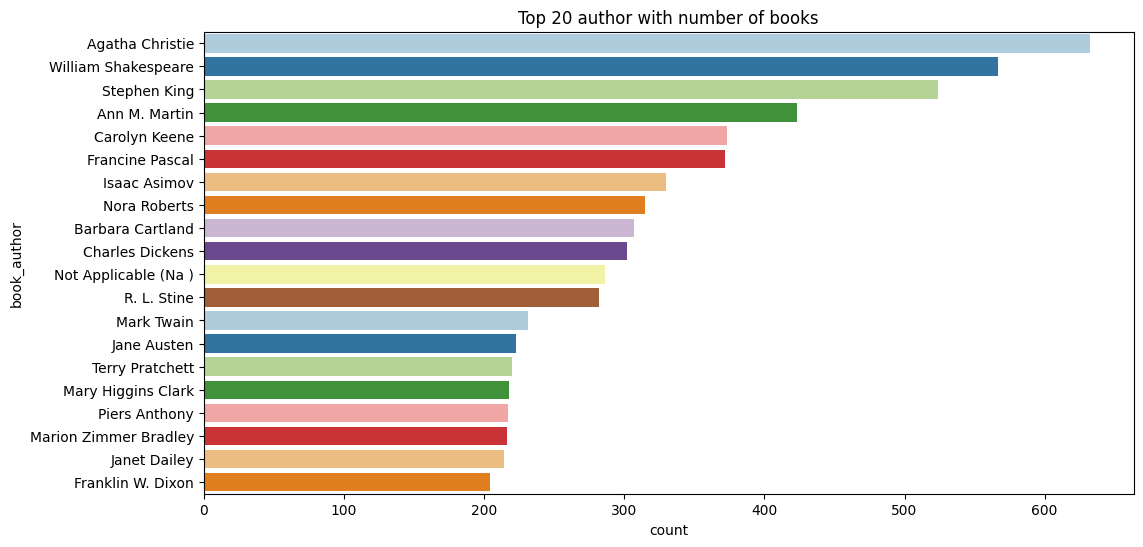

In [ ]:

plt.figure(figsize=(12,6))
sns.countplot(y="book_author",palette = 'Paired', data=book_data,order=book_data['book_author'].value_counts().index[0:20])
plt.title("Top 20 author with number of books")

## Analyse n°1 — Les auteurs les plus représentés

D'après le graphique, **Agatha Christie** est l'auteure la plus représentée dans notre jeu de données, avec plus de **600 livres**, suivie par **William Shakespeare**.

Cependant, le nombre de livres associés à un auteur ne signifie pas nécessairement que cet auteur est le meilleur ou le plus apprécié par les utilisateurs.

Plusieurs hypothèses peuvent être formulées :

- **Agatha Christie** apparaît en première position principalement parce qu'elle possède un grand nombre de livres présents dans le jeu de données. Cela ne signifie pas nécessairement que ses livres sont les mieux notés ou les plus populaires auprès des utilisateurs.
- **William Shakespeare** est également un auteur très connu et populaire, mais il possède moins de livres représentés dans le jeu de données qu'Agatha Christie.
- Certains auteurs moins représentés peuvent néanmoins avoir produit des **livres à très grand succès**, avec un nombre important de lecteurs et de ventes.
- Il est donc important de distinguer le **nombre de livres disponibles** d'un auteur de la **popularité réelle de ses livres** auprès des utilisateurs.

Cette première analyse permet donc de comprendre la répartition des auteurs dans notre dataset, mais elle ne permet pas encore de déterminer quels auteurs ou quels livres sont les plus appréciés.

Pour cela, nous devrons analyser par la suite les **notes attribuées par les utilisateurs** et le **nombre de ratings par livre**.

**Analysis no.2**

Which are top publishers with published books ?

Text(0.5, 1.0, 'Top 20 Publishers with number of books published')

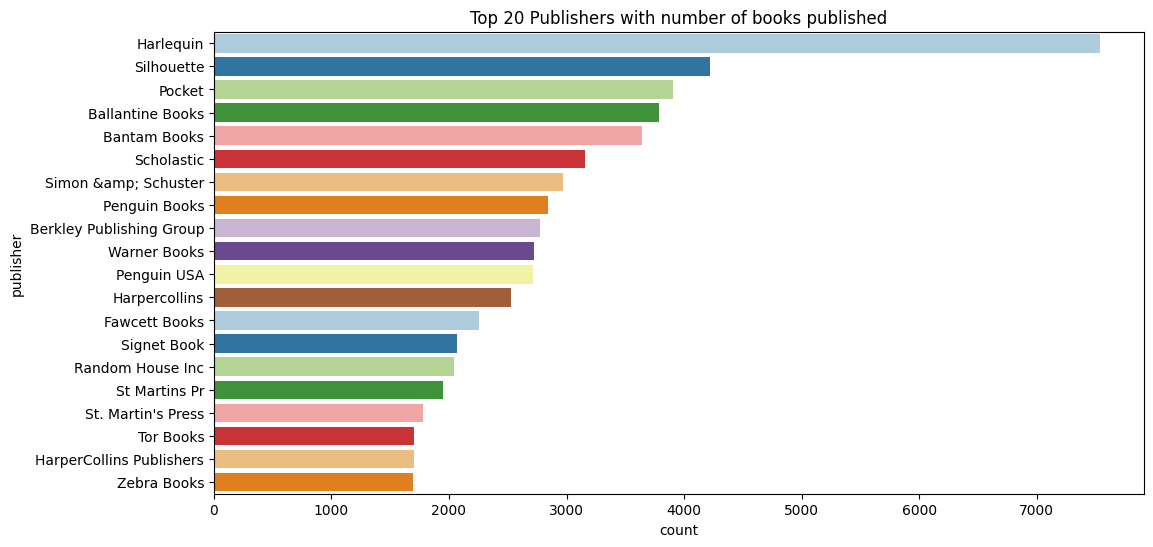

In [ ]:
plt.figure(figsize=(12,6))
sns.countplot(y="publisher",palette = 'Paired', data=book_data,order=book_data['publisher'].value_counts().index[0:20])
plt.title("Top 20 Publishers with number of books published")

## Analyse n°2 — Les éditeurs les plus représentés

Le graphique présente les **10 éditeurs ayant le plus grand nombre de livres dans notre jeu de données**.

On observe que **Harlequin** est l'éditeur le plus représenté dans le dataset, suivi par **Silhouette**. D'autres éditeurs importants apparaissent également, notamment **Penguin Books, Warner Books, Penguin USA** et **Berkley Publishing Group**.

Cette répartition montre que certains éditeurs possèdent une représentation beaucoup plus importante que d'autres dans notre jeu de données. Cela peut être lié à la taille de leur catalogue, à leur ancienneté ou simplement à la manière dont les données ont été collectées.

On peut également remarquer que plusieurs éditeurs importants sont en concurrence avec Harlequin en termes de nombre de livres représentés.

Cependant, **le nombre de livres publiés dans le dataset ne permet pas de déterminer quel éditeur est le meilleur ou le plus apprécié par les utilisateurs**. Un éditeur peut avoir beaucoup de livres présents dans les données sans que ces livres aient nécessairement les meilleures évaluations.

Par exemple, **Penguin Books** possède moins de livres représentés que Harlequin, mais cela ne signifie pas que ses livres sont moins populaires. Il est possible que certains de ses livres aient reçu un grand nombre de notes ou de très bonnes évaluations.

Pour approfondir cette analyse, nous pouvons donc comparer les éditeurs selon **le nombre de ratings, la note moyenne et la popularité de leurs livres**.

Cette analyse nous permet principalement de comprendre la **répartition des livres entre les différents éditeurs** et constitue une première étape de notre analyse exploratoire des données.


**Analysis no.3 -**

Number of Books published in yearly.

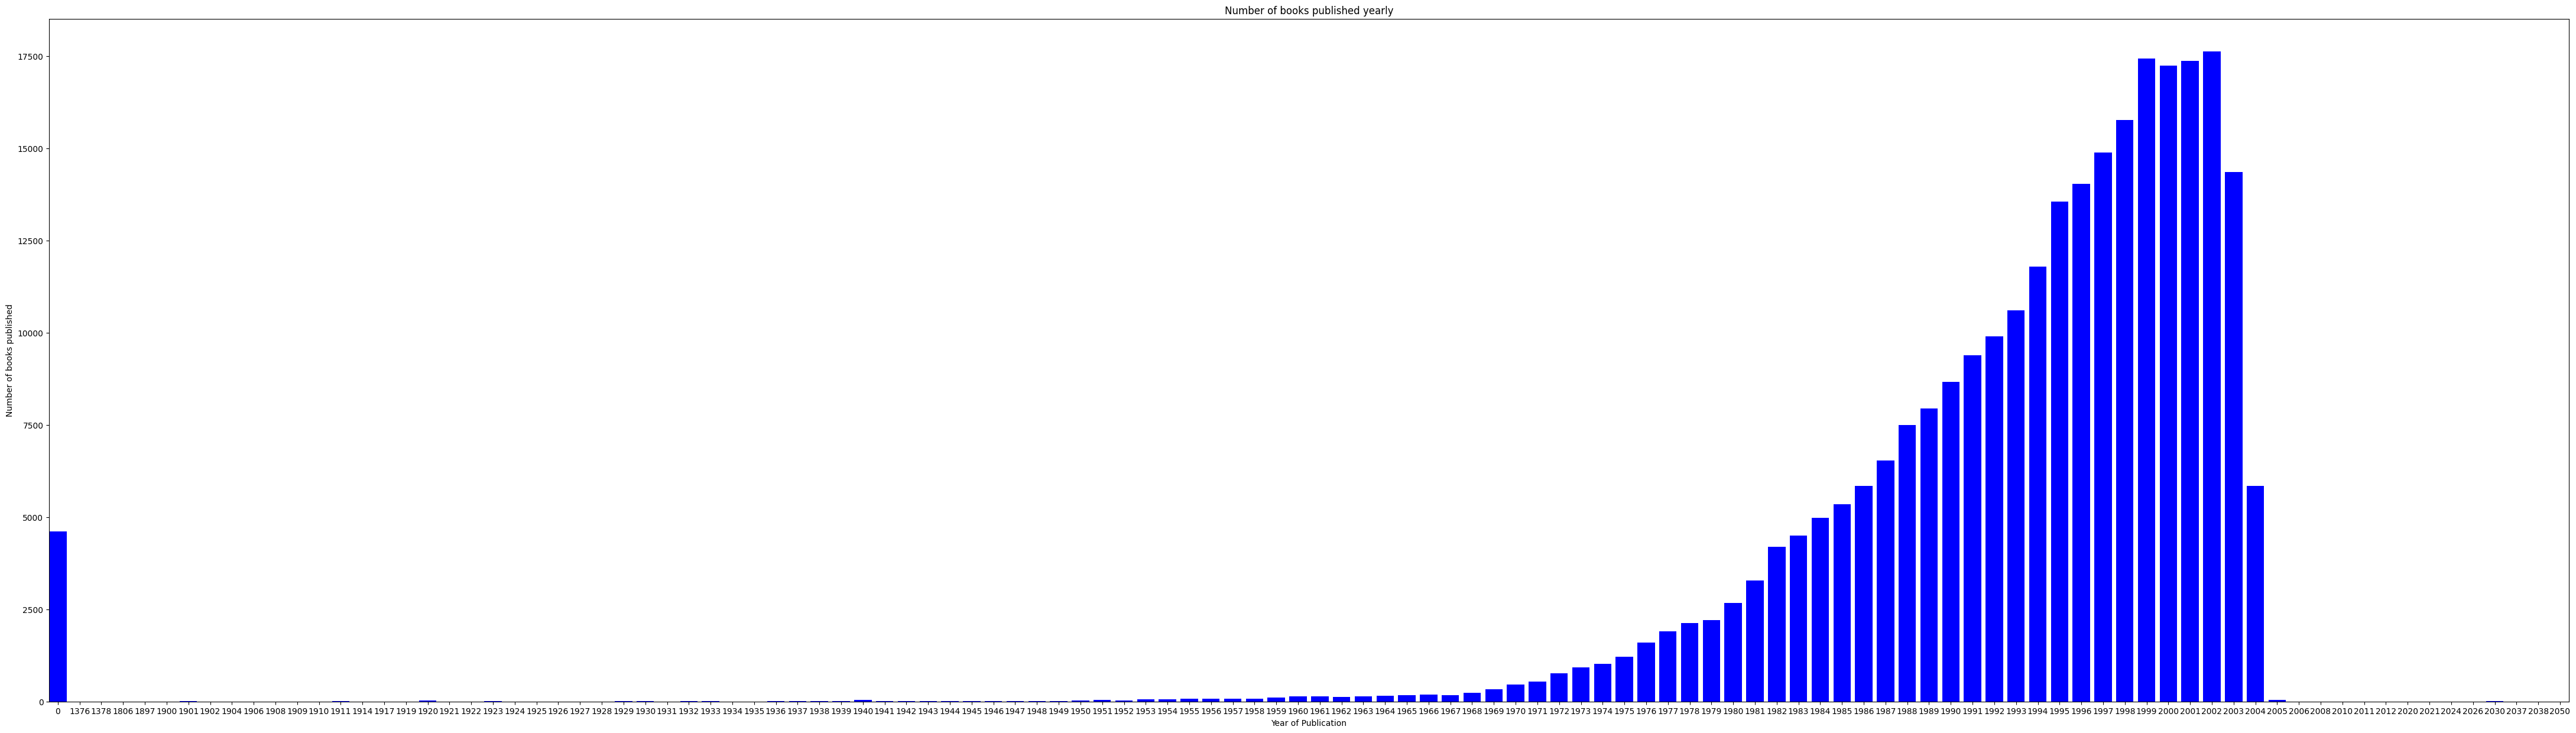

In [ ]:
publications = {}
for year in book_data['year_of_publication']:
    if str(year) not in publications:
        publications[str(year)] = 0
    publications[str(year)] +=1

publications = {k:v for k, v in sorted(publications.items())}

fig = plt.figure(figsize =(55, 15))
plt.bar(list(publications.keys()),list(publications.values()), color = 'blue')
plt.ylabel("Number of books published")
plt.xlabel("Year of Publication")
plt.title("Number of books published yearly")
plt.margins(x = 0)
plt.show()

In [ ]:
book_data.year_of_publication = pd.to_numeric(book_data.year_of_publication, errors='coerce')

# Checking for 0's or NaNs in Year of Publication
zero_year = book_data[book_data.year_of_publication == 0].year_of_publication.count()
nan_year = book_data.year_of_publication.isnull().sum()

print(f'There are {zero_year} entries as \'0\', and {nan_year} NaN entries in the Year of Publication field')

# Replace all years of zero with NaN
book_data.year_of_publication.replace(0, np.nan, inplace=True)

There are 4618 entries as '0', and 0 NaN entries in the Year of Publication field


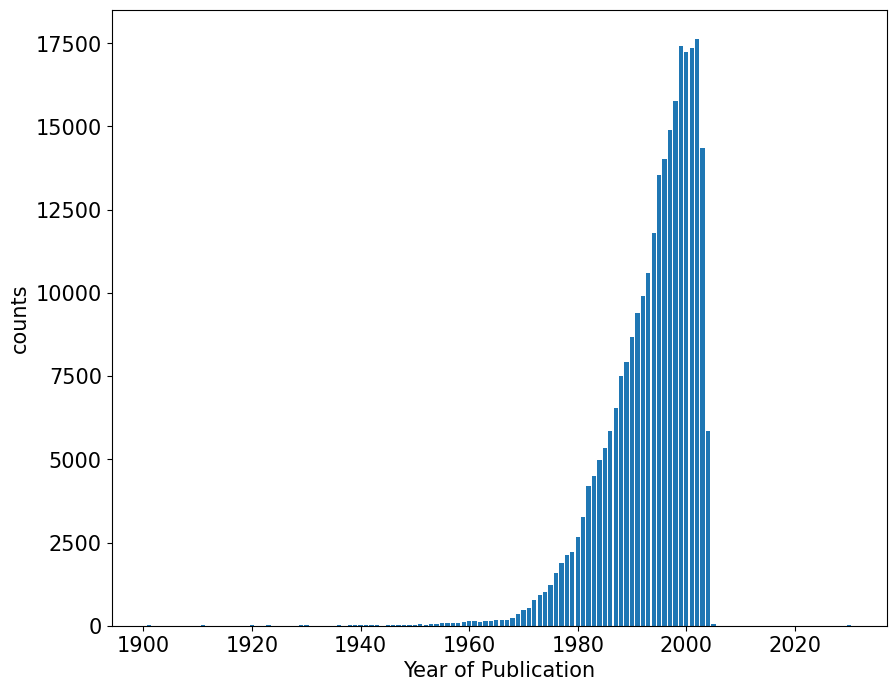

In [ ]:

year = book_data.year_of_publication.value_counts().sort_index()
year = year.where(year>5)
plt.figure(figsize=(10, 8))
plt.rcParams.update({'font.size': 15})
plt.bar(year.index, year.values)
plt.xlabel('Year of Publication')
plt.ylabel('counts')
plt.show()

## Analyse n°3 — Nombre de livres publiés par année

On peut observer que les **années de publication des livres se situent principalement entre 1950 et 2005** dans notre jeu de données.

À partir de 1950, on remarque une augmentation progressive du nombre de livres représentés dans le dataset. Cette évolution peut indiquer une présence de plus en plus importante des ouvrages dans les données au fil des années.

Nous pouvons formuler quelques hypothèses à partir de cette observation :

* **Développement de la lecture :** il est possible que la lecture et l'intérêt pour les livres se soient progressivement développés au cours de cette période, ce qui pourrait expliquer l'augmentation du nombre d'ouvrages représentés.

* **Diversification des goûts des lecteurs :** chaque utilisateur possède ses propres préférences en matière de lecture, qui peuvent dépendre du genre, du sujet abordé ou encore de l'auteur. La diversification des thèmes et des styles littéraires peut donc avoir contribué à l'augmentation du nombre de livres disponibles et recherchés par les lecteurs.

* **Augmentation des données disponibles :** l'un des principaux constats est que le nombre de livres représentés devient particulièrement important à partir des années 1990. Le **pic le plus important se situe approximativement entre 1995 et 2001**.

Cette période représente donc une partie importante de notre dataset. L'augmentation du nombre de livres et des évaluations disponibles peut également fournir davantage d'informations sur les **préférences et les intérêts des utilisateurs**.

Ces informations sont particulièrement intéressantes pour notre **système de recommandation**, car plus nous disposons de livres et de ratings, plus le système peut identifier les préférences des utilisateurs et proposer des recommandations adaptées à leurs goûts.

Cependant, il faut préciser que cette analyse représente uniquement la **distribution des livres dans notre dataset**. Elle ne permet pas à elle seule de conclure que les habitudes de lecture ou la production mondiale de livres ont réellement augmenté pendant ces périodes.



# User_data Dataset


**Analysis no.4 -**
Age distributions of users_data

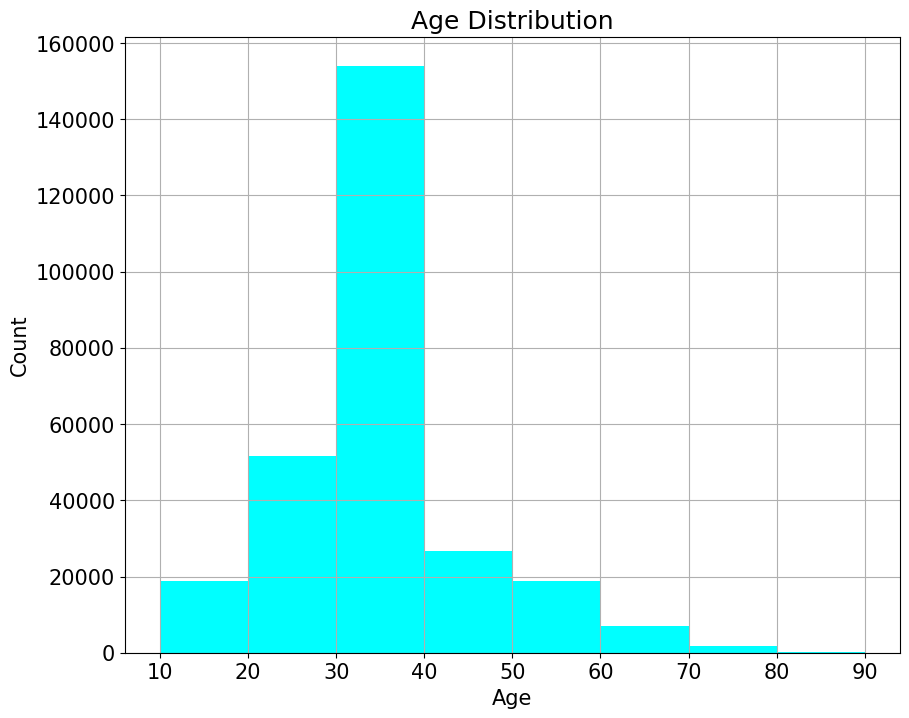

In [ ]:
plt.figure(figsize=(10,8))
users_data.age.hist(bins=[10*i for i in range(1, 10)], color = 'cyan')
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

## Analyse n°4 — Répartition des utilisateurs par âge

En observant la répartition des utilisateurs selon leur âge, on remarque que la tranche d'âge **30–40 ans** est la plus représentée dans notre jeu de données. La tranche **20–30 ans** est également fortement représentée.

Nous pouvons formuler plusieurs hypothèses à partir de cette observation :

* **Les utilisateurs âgés de 30 à 40 ans sont les plus représentés** dans notre dataset. Cela signifie que cette catégorie constitue une part importante des utilisateurs ayant évalué des livres.

* Il est possible que les utilisateurs de cette tranche d'âge soient davantage intéressés par certains **genres, thèmes ou sujets littéraires** proposés par les auteurs présents dans le dataset.

* La tranche d'âge **20–30 ans** présente également une forte représentation. Cela peut indiquer un intérêt important pour la lecture chez les jeunes adultes et une diversité de préférences concernant les auteurs et les genres de livres.

* On observe également une présence des utilisateurs appartenant aux tranches **10–20 ans** et **50–60 ans**, mais leur représentation semble plus faible. Cette différence peut avoir plusieurs explications, notamment les habitudes de lecture, les préférences littéraires ou encore la disponibilité de ces utilisateurs dans le dataset.

Cette analyse est particulièrement intéressante pour notre **système de recommandation**, car l'âge peut potentiellement être utilisé comme une information supplémentaire pour mieux comprendre les préférences des utilisateurs.

Cependant, il est important de préciser que **la présence plus importante d'une tranche d'âge dans le dataset ne signifie pas nécessairement que cette catégorie lit davantage de livres dans la réalité**. Elle indique seulement que cette catégorie est davantage représentée parmi les utilisateurs disponibles dans notre jeu de données.

Pour approfondir cette analyse, nous pourrons étudier la relation entre **l'âge des utilisateurs, leurs notes et les livres qu'ils apprécient**, afin de déterminer s'il existe réellement des différences de préférences entre les différentes catégories d'âge.


# Ratings_data Dataset
**Analysis No. 5**

What are top 20 books as per number of ratings ?

Text(0.5, 1.0, 'Top 20 books as per number of ratings')

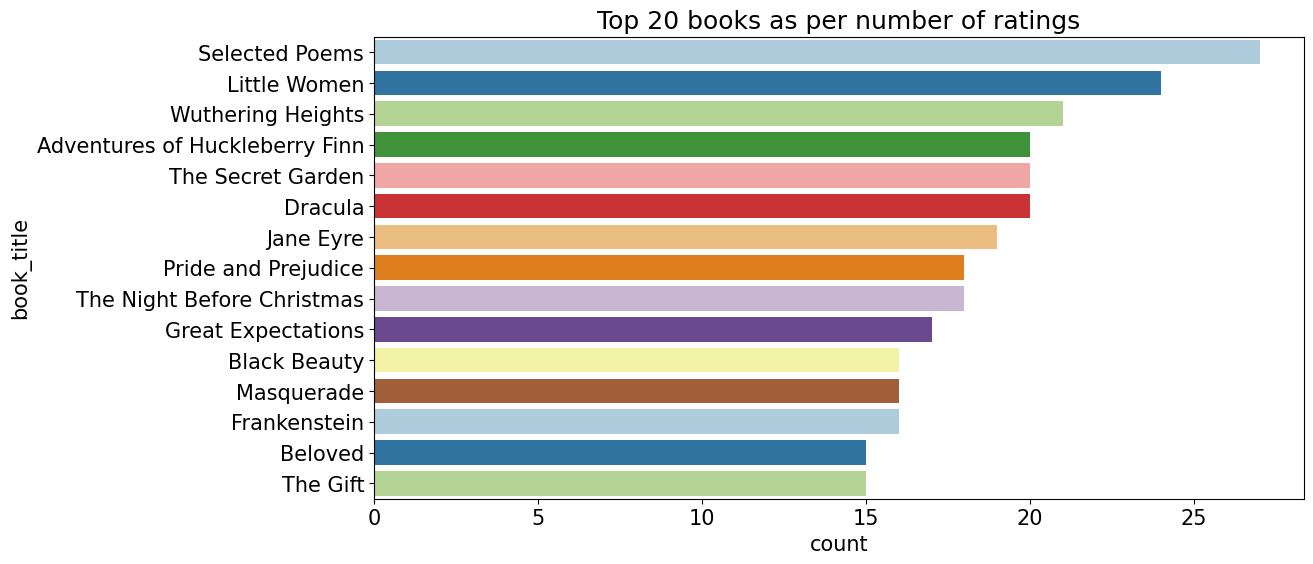

In [ ]:
plt.figure(figsize=(12,6))
sns.countplot(y="book_title",palette = 'Paired',data= book_data, order=book_data['book_title'].value_counts().index[0:15])
plt.title("Top 20 books as per number of ratings")

## Analyse — Les livres les mieux évalués

En analysant les **ratings attribués par les utilisateurs**, on observe que **« Selected Poems »** est le livre qui reçoit le plus grand nombre d’évaluations, suivi de **« Little Women »**.

Quelques observations peuvent être faites :

- **« Selected Poems »** est le livre qui possède le plus grand nombre de ratings dans notre dataset.
- **« Little Women »** arrive en deuxième position, avec également un nombre important d’évaluations.
- **« The Secret Garden »**, **« Dracula »** et **« Adventures of Huckleberry Finn »** présentent des nombres de ratings relativement proches. Ils semblent donc avoir une popularité similaire dans notre dataset.
- De même, **« Masquerade »**, **« Black Beauty »** et **« Frankenstein »** présentent des niveaux de ratings relativement proches.

Cette analyse permet d’identifier les **livres qui ont généré le plus d’interactions auprès des utilisateurs**.

Ces informations sont importantes pour notre **système de recommandation**, car les livres ayant reçu un grand nombre de ratings fournissent davantage d'informations sur les préférences des utilisateurs.

Cependant, il faut distinguer **le nombre de ratings** de **la note moyenne**. Un livre qui possède beaucoup de ratings n'est pas forcément le livre le mieux apprécié. Pour déterminer les livres réellement préférés par les utilisateurs, il serait donc intéressant d'analyser également la **note moyenne de chaque livre**.

Cette analyse nous permettra ainsi de mieux comprendre la **popularité des livres** et de préparer les données nécessaires à la construction de notre système de recommandation.

<Axes: xlabel='book_rating', ylabel='count'>

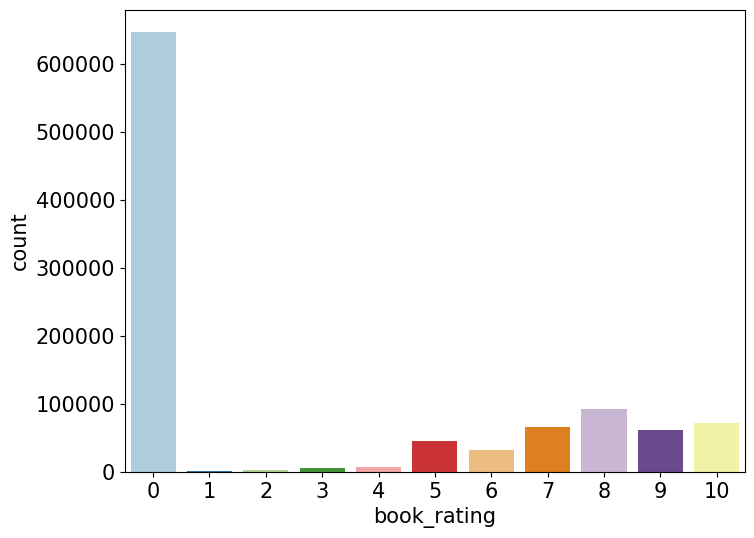

In [ ]:
plt.figure(figsize=(8,6))
sns.countplot(x="book_rating",palette = 'Paired',data= unique_ratings)

## Analyse — Répartition des ratings explicites et implicites

Tout d'abord, les ratings présents dans `ratings_data` sont associés aux livres présents dans `books_data`.

Dans notre dataset, les ratings sont représentés par des valeurs allant de **0 à 10**. Nous pouvons distinguer deux types de ratings :

- **Rating explicite (1–10)** : l'utilisateur a réellement attribué une note au livre.
- **Rating implicite (0)** : l'utilisateur a interagi avec le livre, mais n'a pas attribué de note.

### Observations

Le graphique montre que la valeur **0 est largement majoritaire**. Cela signifie qu'une grande partie des interactions présentes dans le dataset ne contient pas de note explicite de la part des utilisateurs.

Cependant, pour les ratings allant de **1 à 10**, on peut observer une certaine distribution des préférences des utilisateurs.

La note **8** semble être particulièrement fréquente parmi les ratings explicites. Cela peut indiquer que les utilisateurs ont généralement une perception **positive des livres qu'ils évaluent**, sans pour autant leur attribuer systématiquement la note maximale de 10.

On peut donc considérer que les utilisateurs ont tendance à donner des évaluations relativement élevées lorsqu'ils décident de noter un livre.

### Conclusion

Cette distinction entre les **ratings explicites et implicites** est importante pour notre système de recommandation.

Pour construire notre modèle de recommandation basé sur les notes, nous allons principalement nous intéresser aux **ratings explicites (1–10)**, car ils représentent directement les préférences exprimées par les utilisateurs.

Les ratings égaux à **0** pourront être considérés séparément comme des interactions sans évaluation explicite.

Text(0.5, 1.0, 'Explicit Ratings')

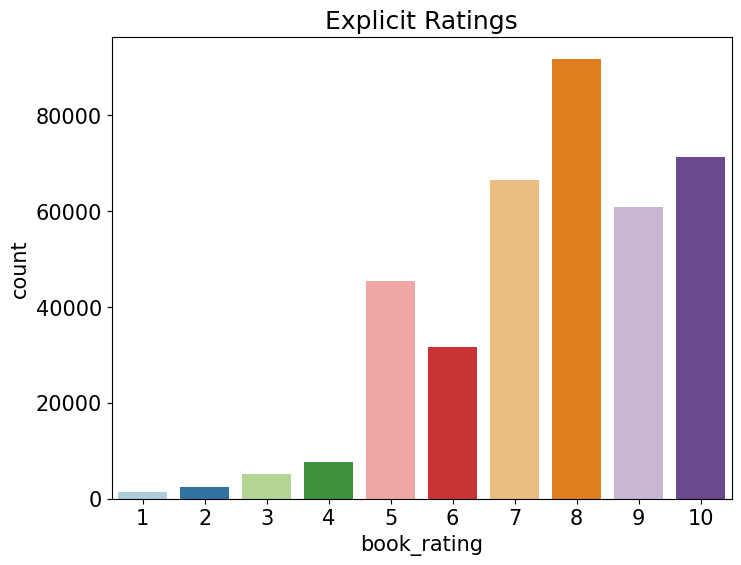

In [ ]:
# Explicit Ratings
plt.figure(figsize=(8,6))
rate_data = unique_ratings[unique_ratings['book_rating'] != 0]
sns.countplot(x="book_rating",palette = 'Paired',data=rate_data)
plt.title("Explicit Ratings")

## Analyse — Distribution des ratings des utilisateurs

Le graphique représentant la distribution de `book_rating` montre que les **notes élevées sont plus fréquentes** parmi les utilisateurs. On remarque notamment que la **note 8** est celle qui apparaît le plus souvent.

À partir de cette distribution, nous pouvons formuler plusieurs hypothèses.

### 🔴 Ratings de 1 à 4 — Évaluations négatives

Les notes comprises entre **1 et 4** peuvent être considérées comme des évaluations plutôt négatives.

Plusieurs raisons peuvent expliquer ces faibles notes :

1. Le contenu ou le **langage utilisé dans le livre** peut ne pas correspondre aux attentes du lecteur.
2. Certains passages, chapitres ou événements du livre peuvent avoir **déplu ou offensé le lecteur**.
3. Le lecteur peut simplement considérer qu'il s'agit d'un **livre de faible qualité ou qui ne correspond pas à ses préférences**.

Ces notes peuvent donc représenter une expérience de lecture négative.

### 🟡 Rating 5 — Évaluation neutre

La note **5** peut être considérée comme une évaluation intermédiaire.

L'utilisateur peut être **indécis** concernant son appréciation du livre. Il peut avoir apprécié certains aspects du livre tout en étant déçu par d'autres.

Ainsi, une note de 5 peut représenter une opinion relativement **neutre ou mitigée**.

### 🟢 Ratings de 6 à 10 — Évaluations positives

Les notes comprises entre **6 et 10** peuvent généralement être considérées comme des évaluations positives.

On remarque que la note **6 est relativement peu fréquente** par rapport aux autres notes de cette catégorie.

Les notes **7 et 8** peuvent être considérées comme des évaluations positives moyennes. La note **8**, qui est la plus fréquente, peut indiquer que les utilisateurs apprécient généralement les livres qu'ils évaluent, sans forcément considérer ces livres comme parfaits.

Les notes **9 et 10** représentent quant à elles les évaluations les plus élevées. Elles peuvent correspondre aux livres que les utilisateurs considèrent comme **excellents ou parmi leurs meilleurs choix**.

### Conclusion

Cette analyse montre une tendance générale vers des **ratings relativement élevés**, avec une forte concentration autour de la note **8**.

La distribution des ratings est particulièrement importante pour notre **système de recommandation**, car elle nous permet de comprendre les préférences des utilisateurs et de distinguer les livres appréciés des livres moins appréciés.

Pour construire notre modèle, nous pourrons utiliser ces ratings explicites afin d'identifier les relations entre les **utilisateurs et les livres**, puis prédire les livres susceptibles de recevoir de bonnes évaluations.

# Système de recommandation

Nous allons maintenant essayer de construire un **système de recommandation basé sur la popularité des livres**, c'est-à-dire principalement sur le **nombre de ratings reçus**.

Ce type de système de recommandation propose généralement les **livres les plus populaires à tous les utilisateurs**, sans prendre en compte leurs caractéristiques personnelles ni leurs préférences individuelles.

L'objectif est donc d'identifier les livres qui ont reçu le plus grand nombre d'évaluations afin de construire une première approche de recommandation basée sur la popularité.

### Séparation des ratings

Dans notre dataset, les ratings sont représentés par des valeurs allant de **0 à 10**.

Nous devons distinguer deux catégories :

- **Ratings explicites (1–10)** : ils correspondent aux notes réellement attribuées par les utilisateurs aux livres. Ils permettent de connaître directement l'appréciation d'un utilisateur.

- **Ratings implicites (0)** : ils indiquent qu'aucune note explicite n'a été attribuée au livre. Ils ne doivent donc pas être interprétés comme une mauvaise note.

Pour construire notre système de recommandation basé sur les ratings, nous allons principalement utiliser les **ratings explicites compris entre 1 et 10**.

Cette première approche nous permettra d'obtenir une liste des **livres les plus populaires**, qui pourra ensuite servir de **modèle de référence (baseline)** avant de passer à des systèmes de recommandation plus personnalisés.

In [ ]:
ratings_explicit= unique_ratings[unique_ratings['book_rating'] != 0]   # explicit ratings represented by 1–10
ratings_implicit= unique_ratings[unique_ratings['book_rating'] == 0]   # implicit ratings represented by 0

In [ ]:

ratings_explicit.head()

,user_id,isbn,book_rating
1,276726,0155061224,5
3,276729,052165615X,3
4,276729,0521795028,6
8,276744,038550120X,7
16,276747,0060517794,9


### Fusion des données `book_data` et `ratings_explicit`

Nous allons maintenant **fusionner les deux jeux de données `book_data` et `ratings_explicit`** afin de préparer les données nécessaires à notre système de recommandation.

Pour cette étape, nous allons uniquement prendre en considération les **ISBN des livres ayant reçu des ratings explicites**, c'est-à-dire des notes comprises entre **1 et 10**.

Les ratings égaux à **0** sont donc exclus de cette analyse, car ils représentent des interactions sans évaluation explicite.

Cette fusion nous permettra d'associer les informations relatives aux livres (titre, auteur, éditeur, etc.) aux **évaluations réellement attribuées par les utilisateurs**.

In [ ]:
print(unique_ratings.shape)
print(ratings_explicit.shape)

(1031136, 3)
(383842, 3)


In [ ]:

# Merging book_data dataset and ratings_explicit
new_book_df= pd.merge(book_data, ratings_explicit, on='isbn')
new_book_df.head()

,isbn,book_title,book_author,year_of_publication,publisher,user_id,book_rating
0,0002005018,Clara Callan,Richard Bruce Wright,2001.0,HarperFlamingo Canada,8,5
1,0002005018,Clara Callan,Richard Bruce Wright,2001.0,HarperFlamingo Canada,11676,8
2,0002005018,Clara Callan,Richard Bruce Wright,2001.0,HarperFlamingo Canada,67544,8
3,0002005018,Clara Callan,Richard Bruce Wright,2001.0,HarperFlamingo Canada,116866,9
4,0002005018,Clara Callan,Richard Bruce Wright,2001.0,HarperFlamingo Canada,123629,9


In [ ]:

print(new_book_df.shape)

(383842, 7)


In [ ]:
new_book_df['book_title'].count()

np.int64(383842)

In [ ]:

new_book_df['book_title'].nunique()

135567

So we've 135567 number of unique values in book_title columns.

# Let's take top 10 recommendation books

In [ ]:
# top ten books as per book ratings and recommendation
top_ten_books= pd.DataFrame(new_book_df.groupby('book_title')['book_rating'].count()
                         .sort_values(ascending=False).head(10))
print('The top ten books as per ratings : ')
top_ten_books

The top ten books as per ratings : 


,book_rating
book_title,
The Lovely Bones: A Novel,707
Wild Animus,581
The Da Vinci Code,494
The Secret Life of Bees,406
The Nanny Diaries: A Novel,393
The Red Tent (Bestselling Backlist),383
Bridget Jones's Diary,377
A Painted House,366
Life of Pi,336


# Memory-Based Collaborative Filtering

Les 10 livres présentés précédemment correspondent simplement aux **10 livres ayant reçu le plus grand nombre de ratings**. Il ne s'agit donc pas encore d'un véritable système de recommandation personnalisé, car les mêmes livres peuvent être proposés à tous les utilisateurs.

Nous allons maintenant utiliser le **Memory-Based Collaborative Filtering**, également appelé **filtrage collaboratif basé sur la mémoire**.

Cette approche utilise l'**historique des interactions entre les utilisateurs et les livres** afin d'identifier des similarités et de générer des recommandations personnalisées.

L'idée principale est que les utilisateurs ayant eu des comportements similaires dans le passé peuvent avoir des préférences similaires pour d'autres livres.

Il existe deux principales approches :

### 1. User-Based Collaborative Filtering

Dans cette approche, nous recherchons des **utilisateurs similaires** en fonction des livres qu'ils ont évalués ou appréciés.

Par exemple, si deux utilisateurs ont donné des ratings similaires à plusieurs livres, ils peuvent être considérés comme des utilisateurs similaires.

Nous pouvons alors recommander à un utilisateur des livres appréciés par des utilisateurs qui lui ressemblent.

**Principe :**

Utilisateur → Utilisateurs similaires → Livres appréciés → Recommandations

### 2. Item-Based Collaborative Filtering

Dans cette approche, nous recherchons des **livres similaires** en fonction des utilisateurs qui les ont évalués.

Si deux livres ont été appréciés par des utilisateurs similaires, nous pouvons considérer qu'ils présentent une certaine similarité.

Ainsi, lorsqu'un utilisateur apprécie un livre, nous pouvons lui recommander d'autres livres similaires.

**Principe :**

Livre apprécié → Livres similaires → Recommandations

### Conclusion

Le Memory-Based Collaborative Filtering permet donc de passer d'une recommandation basée uniquement sur la **popularité** à une recommandation basée sur les **interactions et les préférences des utilisateurs**.

Dans notre projet, nous pouvons tester les deux approches :

- **User-Based** : trouver des utilisateurs similaires.
- **Item-Based** : trouver des livres similaires.

Ces méthodes constitueront une première approche de **recommandation personnalisée** avant d'utiliser des modèles plus avancés comme **SVD**.

# **Train - Test Split**

In [ ]:
from sklearn import model_selection
train_data, test_data = model_selection.train_test_split(new_book_df, test_size=0.20)

In [ ]:
print(f'Training set lengths: {len(train_data)}')
print(f'Testing set lengths: {len(test_data)}')
print(f'Test set is {(len(test_data)/(len(train_data)+len(test_data))*100):.0f}% of the full dataset.')

Training set lengths: 307073
Testing set lengths: 76769
Test set is 20% of the full dataset.


In [ ]:

# Get int mapping for user_id in train dataset
u_unique_train = train_data.user_id.unique()
train_data_user2idx = {o:i for i, o in enumerate(u_unique_train)}

# Get int mapping for isbn in train dataset
i_unique_train = train_data.isbn.unique()
train_data_book2idx = {o:i for i, o in enumerate(i_unique_train)}

In [ ]:
# Get int mapping for user_id in test dataset
u_unique_test = test_data.user_id.unique()
test_data_user2idx = {o:i for i, o in enumerate(u_unique_test)}

# Get int mapping for isbn in test dataset
i_unique_test = test_data.isbn.unique()
test_data_book2idx = {o:i for i, o in enumerate(i_unique_test)}

In [ ]:
# training set
train_data['u_unique'] = train_data['user_id'].map(train_data_user2idx)
train_data['i_unique'] = train_data['isbn'].map(train_data_book2idx)

# testing set
test_data['u_unique'] = test_data['user_id'].map(test_data_user2idx)
test_data['i_unique'] = test_data['isbn'].map(test_data_book2idx)

# Convert back to three feature of dataframe
train_data = train_data[['u_unique', 'i_unique', 'book_rating']]
test_data = test_data[['u_unique', 'i_unique', 'book_rating']]

In [ ]:
train_data.sample(5)


,u_unique,i_unique,book_rating
331715,25493,45825,5
284375,12392,38094,6
131775,41704,62932,10
190665,4160,102170,7
374160,15369,45110,9


In [ ]:

test_data.sample(5)

,u_unique,i_unique,book_rating
45644,3834,770,10
311275,5487,40115,8
334504,5741,30578,8
251115,1490,8329,7
44094,411,10900,7


# **User-Item for Train Data**

In [ ]:
# first I'll create an empty matrix of users books and then I'll add the appropriate values to the matrix by extracting them from the dataset
n_users = train_data['u_unique'].nunique()
n_books = train_data['i_unique'].nunique()

train_matrix = np.zeros((n_users, n_books))

for entry in train_data.itertuples():
    train_matrix[entry[1]-1, entry[2]-1] = entry[3]    # entry[1] is the user-id, entry[2] is the book-isbn and -1 is to counter 0-based indexing

In [ ]:
train_matrix.shape


(59738, 128946)

# **User-Item for Test Data**

In [ ]:
n_users = test_data['u_unique'].nunique()
n_books = test_data['i_unique'].nunique()

test_matrix = np.zeros((n_users, n_books))

for entry in test_data.itertuples():
    test_matrix[entry[1]-1, entry[2]-1] = entry[3]

In [ ]:
test_matrix.shape


(26144, 46887)

## Cosine Similarity Based Recommendation System

La **similarité cosinus (Cosine Similarity)** est une méthode couramment utilisée dans les systèmes de recommandation pour mesurer la **similarité entre deux utilisateurs ou deux livres**.

Dans notre cas, les ratings peuvent être représentés sous forme de **vecteurs dans un espace à plusieurs dimensions**.

Par exemple, chaque dimension peut représenter un livre et la valeur correspondante représente le rating donné par un utilisateur.

La similarité entre deux vecteurs est ensuite calculée en fonction de **l'angle qui les sépare**.

La valeur de la similarité cosinus est généralement comprise entre **-1 et 1** :

- **1** : les deux vecteurs sont très similaires.
- **0** : les deux vecteurs ne présentent pas de similarité particulière.
- **-1** : les deux vecteurs sont opposés.

Dans notre dataset, les ratings sont positifs et compris entre 1 et 10. Nous nous intéresserons donc principalement aux valeurs proches de **1**, qui indiquent des préférences similaires.

### Principe dans notre système de recommandation

La similarité cosinus peut être utilisée selon deux approches :

- **User-Based Collaborative Filtering** : calculer la similarité entre les utilisateurs en fonction de leurs ratings.
- **Item-Based Collaborative Filtering** : calculer la similarité entre les livres en fonction des ratings attribués par les utilisateurs.

Ainsi, si deux utilisateurs présentent des comportements similaires, nous pouvons recommander à l'un des utilisateurs des livres appréciés par l'autre.

De même, si deux livres présentent des profils de ratings similaires, nous pouvons recommander à un utilisateur des livres similaires à ceux qu'il a déjà appréciés.

La similarité cosinus constitue donc une méthode simple et efficace pour commencer à construire un **système de recommandation basé sur le filtrage collaboratif**.

In [ ]:
# To make item-item similarity we need to take the transpose of the matrix
train_matrix_small = train_matrix[:5000, :5000]
test_matrix_small = test_matrix[:5000, :5000]

from sklearn.metrics.pairwise import pairwise_distances
user_similarity = pairwise_distances(train_matrix_small, metric='cosine')
item_similarity = pairwise_distances(train_matrix_small.T, metric='cosine')

In [ ]:
# function to predict the similarity :
def predict_books(ratings, similarity, type='user'): # default type is 'user'
    if type == 'user':
        mean_user_rating = ratings.mean(axis=1)

        # Use np.newaxis so that mean_user_rating has the same format as ratings
        ratings_diff = (ratings - mean_user_rating[:, np.newaxis])
        pred = mean_user_rating[:, np.newaxis] + similarity.dot(ratings_diff) / np.array([np.abs(similarity).sum(axis=1)]).T
    elif type == 'item':
        pred = ratings.dot(similarity) / np.array([np.abs(similarity).sum(axis=1)])
    return pred

In [ ]:
item_prediction = predict_books(train_matrix_small, item_similarity, type='item')
user_prediction = predict_books(train_matrix_small, user_similarity, type='user')

# **Evaluation Metric**

In [ ]:

# Evaluation metric by mean squared error
from sklearn.metrics import mean_squared_error
from math import sqrt

def rmse(prediction, test_matrix):
    prediction = prediction[test_matrix.nonzero()].flatten()
    test_matrix = test_matrix[test_matrix.nonzero()].flatten()
    return sqrt(mean_squared_error(prediction, test_matrix))

print(f'Item-based CF RMSE: {rmse(item_prediction, test_matrix_small)}')
print(f'User-based CF RMSE: {rmse(user_prediction, test_matrix_small)}')

Item-based CF RMSE: 7.964840001990273
User-based CF RMSE: 7.964789372137922


## Système de recommandation basé sur la similarité cosinus

En utilisant la **similarité cosinus** pour construire notre système de recommandation, nous avons obtenu un **RMSE de 7,96**.

Ce résultat indique que les prédictions obtenues avec cette méthode présentent une erreur relativement importante. Nous allons donc essayer d'améliorer les performances de notre système de recommandation en utilisant une autre approche.

Pour cela, nous allons utiliser le modèle **SVD (Singular Value Decomposition)**.

### Approche basée sur un modèle — SVD

Contrairement au **Memory-Based Collaborative Filtering**, qui calcule directement les similarités entre les utilisateurs ou les livres, l'approche **Model-Based** consiste à construire un modèle mathématique capable d'apprendre les relations présentes dans les données.

Le modèle **SVD (Singular Value Decomposition)** est une méthode de factorisation matricielle couramment utilisée dans les systèmes de recommandation.

L'idée est de décomposer la matrice **Utilisateur–Livre** en plusieurs matrices de facteurs latents. Ces facteurs permettent de représenter les préférences des utilisateurs et les caractéristiques des livres sous une forme plus compacte.

Le modèle peut ainsi apprendre les relations entre les utilisateurs et les livres et **prédire le rating qu'un utilisateur pourrait attribuer à un livre qu'il n'a pas encore évalué**.

L'objectif est donc de comparer les performances de SVD avec notre première méthode basée sur la similarité cosinus et de vérifier si le **RMSE peut être amélioré**.

### Objectif

Nous allons donc :

1. Préparer les ratings explicites.
2. Diviser les données en **train set** et **test set**.
3. Entraîner le modèle **SVD**.
4. Prédire les ratings sur les données de test.
5. Calculer le **RMSE**.
6. Comparer les performances avec la méthode basée sur la similarité cosinus.

Cette étape nous permettra de déterminer si l'approche **Model-Based Collaborative Filtering avec SVD** est plus performante pour notre système de recommandation.

In [ ]:
!pip install scikit-surprise

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 31.4 MB/s eta 0:00:00


In [ ]:
from surprise import Reader, Dataset


In [ ]:
# Creating a 'Reader' object to set the limit of the ratings
reader = Reader(rating_scale=(1, 10))
data = Dataset.load_from_df(ratings_explicit, reader)

In [ ]:
from surprise import SVD, model_selection, accuracy
model = SVD()

# Train on books dataset
%time model_selection.cross_validate(model, data, measures=['RMSE'], cv=5, verbose=True)

Evaluating RMSE of algorithm SVD on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
RMSE (testset)    1.6362  1.6390  1.6303  1.6380  1.6349  1.6357  0.0030  
Fit time          7.08    6.53    6.26    7.09    6.43    6.68    0.34    
Test time         0.72    1.09    0.74    0.45    0.73    0.75    0.20    
CPU times: user 43.4 s, sys: 416 ms, total: 43.8 s
Wall time: 45 s


{'test_rmse': array([1.63619726, 1.63896479, 1.63031506, 1.63797155, 1.63488944]),
 'fit_time': (7.080363988876343,
  6.527001857757568,
  6.259143590927124,
  7.086592197418213,
  6.427786111831665),
 'test_time': (0.7189202308654785,
  1.0885698795318604,
  0.7396504878997803,
  0.45287227630615234,
  0.733736515045166)}

# **Train - Test Split**

In [ ]:

# train and test split
trainset, testset = model_selection.train_test_split(data, test_size=0.2)

# SVD model
model = SVD()
model.fit(trainset)

# **Evaluation metrics for SVD model**

In [ ]:
# displaying RMSE score
predictions = model.test(testset)
print(f"The accuracy is {accuracy.rmse(predictions)}")

RMSE: 1.6406
The accuracy is 1.6406147330796035


The RMSE score is better now with 1.64.

In [ ]:
# to test result let's take an user-id and item-id to test our model.
uid = 276744
iid = '038550120X'
pred = model.predict(uid, iid, verbose=True)

user: 276744     item: 038550120X r_ui = None   est = 7.32   {'was_impossible': False}


In [ ]:
# display estimated rating and real rating
print(f'The estimated rating for the book with ISBN code {pred.iid} from user #{pred.uid} is {pred.est:.2f}.\n')
actual_rtg= ratings_explicit[(ratings_explicit.user_id==pred.uid) &
                             (ratings_explicit.isbn==pred.iid)].book_rating.values[0]
print(f'The real rating given for this was {actual_rtg:.2f}.')

The estimated rating for the book with ISBN code 038550120X from user #276744 is 7.32.

The real rating given for this was 7.00.


In [ ]:
# The following function was adapted from the surprise docs
# and can be used to get the top book recommendations for each user.
from collections import defaultdict

def get_top_n(predictions, n=10):

    # First map the predictions to each user
    top_n = defaultdict(list)
    for uid, iid, true_r, est, _ in predictions:
        top_n[uid].append((iid, est))

    # Then sort the predictions for each user and retrieve the k highest ones
    for uid, user_ratings in top_n.items():
        user_ratings.sort(key=lambda x: x[1], reverse=True)
        top_n[uid] = user_ratings[:n]

    return top_n

In [ ]:

# prediciton on teset and getting top predictions
pred = model.test(testset)
top_n = get_top_n(pred)

In [ ]:
pred_testset_df = pd.DataFrame(pred)
pred_testset_df

,uid,iid,r_ui,est,details
0,136348,1586216953,7.0,6.979683,{'was_impossible': False}
1,176966,0380977281,9.0,7.729536,{'was_impossible': False}
2,177374,0671744593,8.0,8.417489,{'was_impossible': False}
3,144062,0679450742,10.0,7.441556,{'was_impossible': False}
4,115701,0439136350,10.0,8.644374,{'was_impossible': False}
...,...,...,...,...,...
76764,199495,0312306326,7.0,7.174916,{'was_impossible': False}
76765,225886,0553268945,8.0,8.447064,{'was_impossible': False}
76766,71102,0553277472,8.0,7.782184,{'was_impossible': False}
76767,192230,0380792648,10.0,7.419894,{'was_impossible': False}


In [ ]:
def get_reading_list(userid):

    reading_list = defaultdict(list)
    top_n = get_top_n(pred, n=10)
    for n in top_n[userid]:
        book, rating = n
        title = new_book_df.loc[new_book_df.isbn==book].book_title.unique()[0]
        reading_list[title] = rating
    return reading_list

In [ ]:
#take a random look at user_id
example_reading_list = get_reading_list(userid=116866)
for book, rating in example_reading_list.items():
    print(f'{book}: {rating}')

Attack Of The Deranged Mutant Killer Snow Goons: 8.794008268329558
Chaos: Making a New Science: 8.04266268305069
The Complete Idiot's Guide to Javascript: 7.756239809231504
The Best of Creative Computing: 7.756239809231504
SHIPPING NEWS: 7.736709586976868
Generation X: Tales for an Accelerated Culture: 7.734403491494577
In search of excellence: Lessons from America's best-run companies: 7.710646865543615
The Progress of Love (King Penguin): 7.703673604843447


In [ ]:
user_id = 276744

In [ ]:
user_counts = ratings_explicit['user_id'].value_counts()

user_counts.head(20)

,count
user_id,
11676,6943
98391,5691
189835,1899
153662,1845
23902,1180
235105,1020
76499,1012
171118,962
16795,959


In [ ]:
user_id = user_counts.index[0]

print("User ID :", user_id)
print("Nombre de ratings :", user_counts.iloc[0])

User ID : 11676
Nombre de ratings : 6943


In [ ]:
user_ratings = ratings_explicit[
    ratings_explicit['user_id'] == user_id
].merge(
    book_data,
    on='isbn'
)

user_ratings[
    ['book_title', 'book_author', 'book_rating']
].sort_values(
    'book_rating',
    ascending=False
).head(10)

,book_title,book_author,book_rating
6908,La concessione del telefono (La Memoria),Andrea Camilleri,10
2013,"The Two Towers (The Lord of the Rings, Part 2)",J. R. R. Tolkien,10
2012,"The Return of the King (The Lord of the Rings,...",J. R. R. Tolkien,10
2003,Cat in the Hat (I Can Read It All by Myself Be...,Seuss,10
2000,A Visit to the Sesame Street Firehouse: Featur...,Dan Elliott,10
1996,Juniper,MONICA FURLONG,10
1990,Aliens for Breakfast,Jonathan Etra,10
1989,The Phantom Tollbooth,Norton Juster,10
1988,Babar the King (Babar Books (Random House)),Jean De Brunhoff,10
6922,Retrato En Sepia,Isabel Allende,10


In [ ]:
def recommend_books(user_id, n=10):

    # Livres déjà notés par l'utilisateur
    rated_books = set(
        ratings_explicit[
            ratings_explicit['user_id'] == user_id
        ]['isbn']
    )

    # Tous les livres
    all_books = set(book_data['isbn'])

    # Livres jamais notés
    unrated_books = all_books - rated_books

    predictions = []

    for isbn in unrated_books:

        prediction = model.predict(
            user_id,
            isbn
        )

        predictions.append(
            (isbn, prediction.est)
        )

    # Trier par rating prédit
    predictions.sort(
        key=lambda x: x[1],
        reverse=True
    )

    top_books = predictions[:n]

    # Transformer ISBN → informations livre
    recommendations = []

    for isbn, predicted_rating in top_books:

        book = book_data[
            book_data['isbn'] == isbn
        ].iloc[0]

        recommendations.append({
            'ISBN': isbn,
            'Book': book['book_title'],
            'Author': book['book_author'],
            'Predicted Rating': round(
                predicted_rating, 2
            )
        })

    return pd.DataFrame(recommendations)

In [ ]:
recommend_books(user_id, 10)

,ISBN,Book,Author,Predicted Rating
0,0310205719,The Purpose-Driven Life: What on Earth Am I He...,Rick Warren,10.00
1,0439425220,Harry Potter and the Chamber of Secrets Postca...,J. K. Rowling,10.00
2,0060930535,The Poisonwood Bible: A Novel,Barbara Kingsolver,10.00
3,0399501487,Lord of the Flies,William Gerald Golding,10.00
4,0060976845,Little Altars Everywhere: A Novel,Rebecca Wells,10.00
5,0385486804,Into the Wild,Jon Krakauer,10.00
6,0330332775,Bridget Jones's Diary,Helen Fielding,10.00
7,0440211727,A Time to Kill,JOHN GRISHAM,9.84
8,0385509510,Under the Banner of Heaven : A Story of Violen...,JON KRAKAUER,9.75
9,0374516812,The Lottery and Other Stories,Shirley Jackson,9.69
